In [1]:
# Model
ENCODER_MODEL_PATH = "/project/lt200324-optmul/pluem/model/trocr-base-handwritten"
DECODER_MODEL_PATH = "/project/lt200324-optmul/pluem/model/huggingface_electra-small-25000-no-grad-small"

In [2]:
from transformers import (
    VisionEncoderDecoderModel,
    TrOCRProcessor,
    AutoModelForCausalLM,
    AutoTokenizer,
    AutoConfig,
    AdamW,
    get_linear_schedule_with_warmup,
)

tokenizer = AutoTokenizer.from_pretrained(DECODER_MODEL_PATH)

/lustrefs/disk/project/lt200324-optmul/pluem/env/lib/python3.10/site-packages/transformers/utils/hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [25]:
import pandas as pd

# Specify the path to your file
file_path = '/project/lt200324-optmul/pluem/version_3/dataset/name/name.txt'

# Read the file into a list
with open(file_path, 'r') as file:
    lines = file.readlines()

# Optionally, strip newline characters from each line
lines = [line.strip() for line in lines]

In [26]:
# Create a DataFrame from the list
df = pd.DataFrame(lines, columns=['text'])
df['text'] = df['text'].str.strip()
# Display the DataFrame
print(df)

                                text
0                  อิสริยา วุฑฒิโชติ
1                       มนัสพร ตปาคม
2                 จ่าตรีสุชาติ เทพธร
3            ร.อ. จิตรีภรณ์ กีสะบุตร
4                  ซูฮัยดา ยุกตานนท์
...                              ...
4999995    พันเรือตรีวรรณา สาริกาดิษ
4999996             มุธิตา อัมพะผลิน
4999997  พลเอก ฐานพัฒน์ สัมปันนานนท์
4999998      พันตรีฟาฮาน่า ตัณฑสินธุ
4999999      ร.ร.ท. ภีมพัฒน์ ตันตาคม

[5000000 rows x 1 columns]


In [27]:
from tqdm import tqdm
# Enable tqdm to display progress
tqdm.pandas()

# Tokenize the text and calculate the desired ratio
def compute_ratio(row):
    tokens = tokenizer(row['text'], return_tensors='pt')
    input_ids_length = len(tokens["input_ids"][0])  # Get length of input_ids
    text_length = len(row['text'])
    return text_length / input_ids_length if input_ids_length > 0 else 0

# Use tqdm to show a progress bar while applying the function
df['length_ratio'] = df.progress_apply(compute_ratio, axis=1)

# Display the DataFrame
print(df)

100%|██████████| 5000000/5000000 [15:40<00:00, 5317.58it/s]

                                text  length_ratio
0                  อิสริยา วุฑฒิโชติ      1.416667
1                       มนัสพร ตปาคม      1.333333
2                 จ่าตรีสุชาติ เทพธร      2.000000
3            ร.อ. จิตรีภรณ์ กีสะบุตร      1.533333
4                  ซูฮัยดา ยุกตานนท์      1.545455
...                              ...           ...
4999995    พันเรือตรีวรรณา สาริกาดิษ      2.083333
4999996             มุธิตา อัมพะผลิน      1.454545
4999997  พลเอก ฐานพัฒน์ สัมปันนานนท์      2.454545
4999998      พันตรีฟาฮาน่า ตัณฑสินธุ      1.916667
4999999      ร.ร.ท. ภีมพัฒน์ ตันตาคม      1.352941

[5000000 rows x 2 columns]


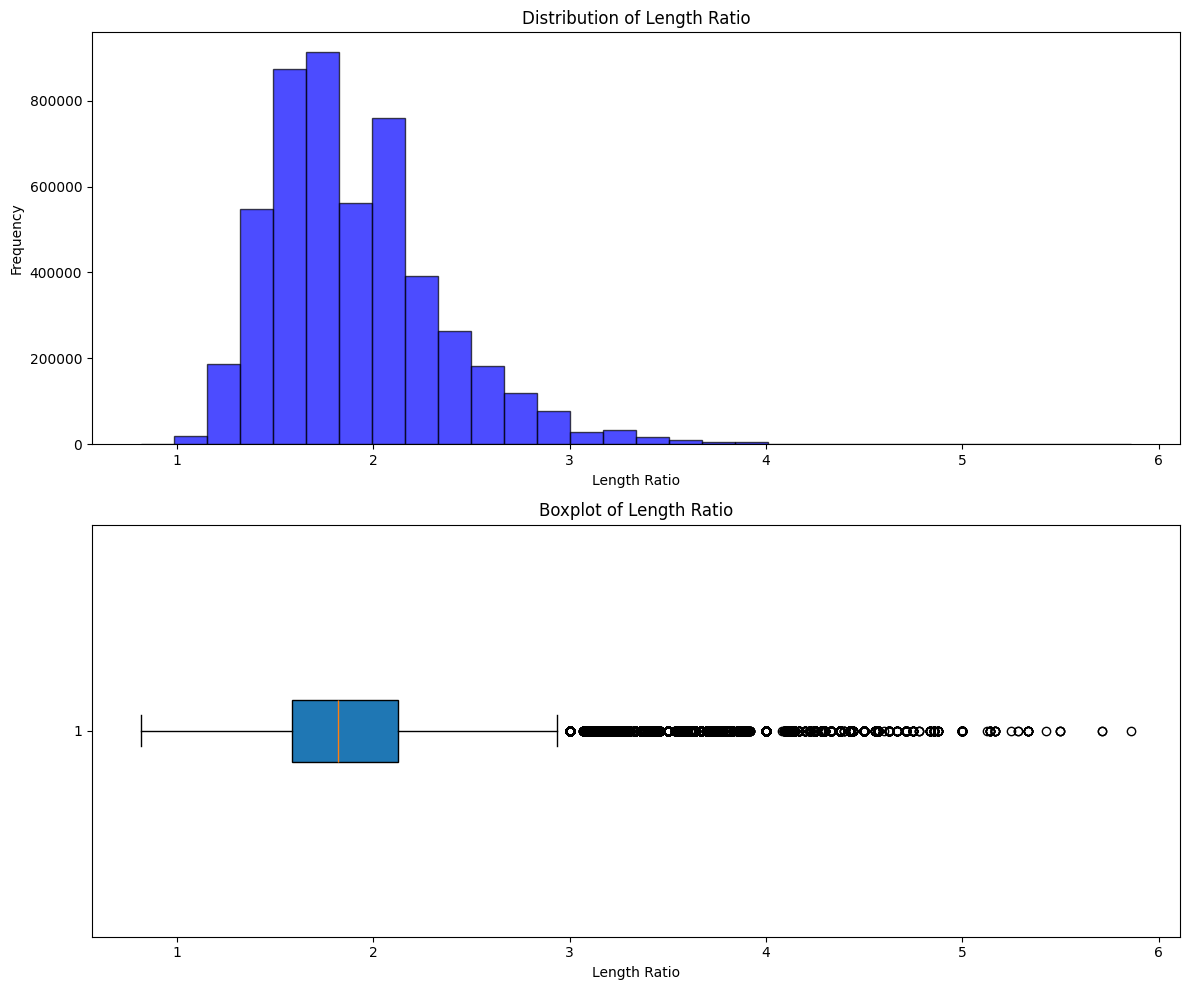

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with 'length_ratio' column

# Create a figure with two subplots: a histogram and a boxplot
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# Histogram
axs[0].hist(df['length_ratio'], bins=30, color='blue', alpha=0.7, edgecolor='black')
axs[0].set_title('Distribution of Length Ratio')
axs[0].set_xlabel('Length Ratio')
axs[0].set_ylabel('Frequency')

# Boxplot
axs[1].boxplot(df['length_ratio'], vert=False, patch_artist=True)
axs[1].set_title('Boxplot of Length Ratio')
axs[1].set_xlabel('Length Ratio')

# Show the plots
plt.tight_layout()
plt.show()


In [35]:
# Filter rows where length_ratio > 3.5
high_length_ratio_rows = df[df['length_ratio'] > 3.5]

# Display the filtered rows
print(high_length_ratio_rows)

                                           text  length_ratio
491        ผู้ช่วยศาสตราจารย์บวรภัค วิทักษะบุตร      3.600000
1015       รองศาสตราจารย์ พลอยชมพู สุคนธาภิรมย์      3.600000
1104          รองศาสตราจารย์ พัชจิรา สุทธิสุนทร      3.666667
1221          รองศาสตราจารย์สิรภูมิ โกมลพราหมณ์      3.666667
1742     ผู้ช่วยศาสตราจารย์ เพลงภัสสร สุขกนิษฐ์      3.800000
...                                         ...           ...
4998949        รองศาสตราจารย์ปรียพันธุ์ วีรศิริ      3.555556
4999244       รองศาสตราจารย์ภาณุวิชญ์ สุวรรณคดี      4.714286
4999491      รองศาสตราจารย์ จักรพันธ์ โกมลานนท์      3.777778
4999654   รองศาสตราจารย์จินต์จุฑา จันทนิยมานนท์      3.700000
4999709        รองศาสตราจารย์นิตินันท์ บุญจินดา      4.571429

[23368 rows x 2 columns]


In [38]:
# Drop rows where length_ratio > 4
df_filtered = df[df['length_ratio'] <= 3.5]

# Display the number of rows after filtering
print(f'Number of rows after dropping: {df_filtered.shape[0]}')

# Optionally, display the filtered DataFrame
print(df_filtered)

Number of rows after dropping: 4976632
                                text  length_ratio
0                  อิสริยา วุฑฒิโชติ      1.416667
1                       มนัสพร ตปาคม      1.333333
2                 จ่าตรีสุชาติ เทพธร      2.000000
3            ร.อ. จิตรีภรณ์ กีสะบุตร      1.533333
4                  ซูฮัยดา ยุกตานนท์      1.545455
...                              ...           ...
4999995    พันเรือตรีวรรณา สาริกาดิษ      2.083333
4999996             มุธิตา อัมพะผลิน      1.454545
4999997  พลเอก ฐานพัฒน์ สัมปันนานนท์      2.454545
4999998      พันตรีฟาฮาน่า ตัณฑสินธุ      1.916667
4999999      ร.ร.ท. ภีมพัฒน์ ตันตาคม      1.352941

[4976632 rows x 2 columns]


In [39]:
text_data = "\n".join(df_filtered['text'])

# Specify the path where you want to save the file
output_file_path = '/project/lt200324-optmul/pluem/version_3/dataset/name/name.txt'

# Write the string to the .txt file
with open(output_file_path, 'w', encoding='utf-8') as file:
    file.write(text_data)

print(f'Data saved to {output_file_path}')

Data saved to /project/lt200324-optmul/pluem/version_3/dataset/name/name.txt
